In [1]:
# To check if the DQN works fine
# Modifications: Different Environment, and using consecutive current
import os
import numpy as np
import torch
import torch.optim as optim
import utils

from simple_environment import SimpleLattice
from DQN import ReplayMemory, DQN
from dynamics import Dynamics
from utils import Storage, Visualization

import matplotlib.pyplot as plt
from IPython.display import HTML

In [8]:
if __name__ == "__main__":

    runsNumber = 100
    if torch.cuda.is_available():
        totalMCS = 600
    else:
        totalMCS = 50

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    Load = False

    # Hyperparameters for environment
    env_params = {
        'render_mode': None,
        'mode': "random",        
        'Lx': 12,
        'Ly': 1,
        'N': 1,
        'max_steps': 1,
        'mu': 0.5, 
        'fixed_sigma': 0.001                       
    }

    # Hyperparameters for reinforcement learning algorithm
    rl_params = {
        'BATCH_SIZE': 128,
        'GAMMA': 0.99,
        'EPS_START': 0.9,
        'EPS_END': 0.05,
        'EPS_DECAY': 2000,
        'TAU': 5e-3,
        'LR': 1e-3
    }

    # ================================================== 
    # Initialize environment
    # ================================================== 
    env = SimpleLattice(env_params)
    playground = Dynamics(env_params, rl_params, device, log = False)

    # ================================================== 
    # Initialize reinforcement learning algorithm
    # ================================================== 
    n_actions = env.action_space.n     # Get number of actions from gym action space: The number of particles in the system
    state, info = env.reset()     # Get the number of state observations: The size of the lattice Lx*Ly (int from 0 to Lx*Ly or an array with labelled particles)
    n_observations = np.size(state) 
    policy_net = DQN(n_observations, n_actions).to(device)  # We create an instance of DQN, and move it to the device
    target_net = DQN(n_observations, n_actions).to(device)    
    memory = ReplayMemory(10000)
    storage = Storage(env_params, rl_params, runsNumber, totalMCS)

    if Load == False:
        target_net.load_state_dict(policy_net.state_dict()) # Using fixed parameters from the policy network. 
                                                        # state_dict(): Python dictionary object that maps each layer to its parameter tensor (W,B)       
    else:
        utils.load_data_from_file('training_storage.pkl', training_storage)
        policy_net.load_state_dict(training_storage['policy_NN'])
        target_net.load_state_dict(training_storage['target_NN'])
        memory.fill(training_storage['memory'])

    optimizer = optim.AdamW(policy_net.parameters(), lr=rl_params['LR'], amsgrad=True)

    CurrentAlongTot, lossTot, rewardsTot, JumpRate_movie, JumpRate_short_movie = playground.simulate(runsNumber, totalMCS, memory, policy_net, target_net, optimizer)

    training_storage, data_storage = storage.update_dictionaries(policy_net, target_net, memory, CurrentAlongTot, lossTot, rewardsTot)

    if Load == False:
        utils.save_data_to_file('training_storage.pkl', training_storage)    
        utils.save_data_to_file('data_storage.pkl', data_storage)
    else:
        runsNumber = training_storage['hyperparameters']['runsNumber'] + runsNumber
        totalMCS = training_storage['hyperparameters']['totalMCS'] + totalMCS
        utils.save_data_to_file('training_storage.pkl', training_storage)
        utils.save_data_to_file('data_storage.pkl', data_storage)

    #print('Current Along Total', CurrentAlongTot)

100%|██████████| 100/100 [00:12<00:00,  8.00it/s]


Complete


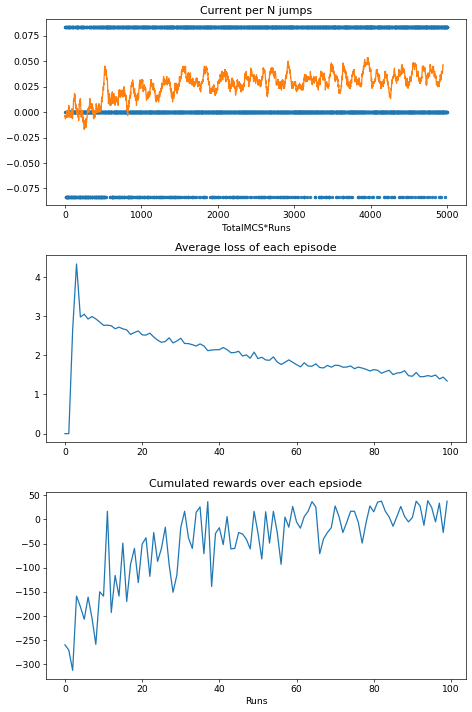

In [9]:
plot = Visualization(data_storage)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 60
plt.rcParams["font.size"] = 11

plot.create_combined_plot(env_params['Lx'], env_params['Ly'], env_params['fixed_sigma'], rl_params['LR'])

In [4]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_animation(Frames_movie):
    fig, ax = plt.subplots()
    div = make_axes_locatable(ax)
    cax = div.append_axes('right', '5%', '5%')
    
    cv0 = Frames_movie[0]
    im = ax.imshow(cv0, cmap="gnuplot")
    cb = fig.colorbar(im, cax=cax)
    
    tx2 = ax.set_title('Frame 0 after one MCS of the last run', y=1)
    
    ax.axis('off')
    plt.close()  # To not have the plot of frame 0

    def animate(frame):
        arr = Frames_movie[frame]
        vmax = 1
        vmin = np.min(arr)
        im.set_data(arr)
        im.set_clim(vmin, vmax)
        cb.ax.set_ylabel('Jumping Rate')
        tx2.set_text('Frame {0}'.format(frame))

    ani = FuncAnimation(fig, animate, frames=len(JumpRate_short_movie), repeat=False)
    return ani


# Movie
ani = create_animation(JumpRate_short_movie)
HTML(ani.to_jshtml())
#ani.save('Pictures/animation_4x2.mp4')